#Basics of Probability

In [1]:
import random

# 1a. Tossing a coin 10,000 times
def coin_toss_simulation(n=10000):
    outcomes = [random.choice(['Heads', 'Tails']) for _ in range(n)]
    heads_count = outcomes.count('Heads')
    tails_count = outcomes.count('Tails')
    return heads_count / n, tails_count / n

# 1b. Rolling two dice to get a sum of 7
def dice_sum_seven(n=10000):
    success = 0
    for _ in range(n):
        die1 = random.randint(1, 6)
        die2 = random.randint(1, 6)
        if die1 + die2 == 7:
            success += 1
    return success / n

h_prob, t_prob = coin_toss_simulation()
seven_prob = dice_sum_seven()

print(f"Prob(Heads): {h_prob}, Prob(Tails): {t_prob}")
print(f"Prob(Sum of 7): {seven_prob}")

Prob(Heads): 0.504, Prob(Tails): 0.496
Prob(Sum of 7): 0.1646


#Explanation: For the coin toss, we use random.choice to pick between two outcomes and repeat it 10,000 times to find the relative frequency. For the dice, we generate two random integers between 1 and 6 and count how many times their sum equals 7.

Probability of at least one "6"

In [2]:
def estimate_at_least_six(trials=10000, rolls_per_trial=10):
    success_trials = 0
    for _ in range(trials):
        rolls = [random.randint(1, 6) for _ in range(rolls_per_trial)]
        if 6 in rolls:
            success_trials += 1
    return success_trials / trials

prob_at_least_six = estimate_at_least_six()
print(f"Probability of at least one '6' in 10 rolls: {prob_at_least_six}")

Probability of at least one '6' in 10 rolls: 0.8383


Explanation: We run 10,000 trials where each trial consists of 10 rolls 1 . If a '6' appears at least once in those 10 rolls, the trial is marked as a success 1

Conditional probability & Bayes theorem . 

In [3]:
def bayes_simulation(n=1000):
    bag = ['Red']*5 + ['Green']*7 + ['Blue']*8
    history = [random.choice(bag) for _ in range(n)]
    
    blue_prev_count = 0
    red_given_blue_count = 0
    
    for i in range(1, n):
        if history[i-1] == 'Blue':
            blue_prev_count += 1
            if history[i] == 'Red':
                red_given_blue_count += 1
                
    prob_red_given_blue = red_given_blue_count / blue_prev_count
    return prob_red_given_blue

print(f"P(Red | Previous was Blue): {bayes_simulation()}")

P(Red | Previous was Blue): 0.24938271604938272


Explanation: By simulating 1,000 draws, we filter for instances where the previous ball was blue and then calculate what fraction of the next draws were red 1 . Since the ball is put back (replacement), these events are independent, so $P(Red|Blue)$ should be close to the theoretical $P(Red) = 5/20 = 0.25$ 1 


#Discrete Random Variables

In [4]:
import numpy as np

values = [1, 2, 3]
probs = [0.25, 0.35, 0.4]
sample = np.random.choice(values, size=1000, p=probs)

print(f"Empirical Mean: {np.mean(sample)}")
print(f"Empirical Variance: {np.var(sample)}")
print(f"Standard Deviation: {np.std(sample)}")

Empirical Mean: 2.168
Empirical Variance: 0.6157759999999999
Standard Deviation: 0.7847139606251439


Explanation: We generate a sample of 1,000 numbers based on the weighted probabilities provided 1 . We then use numpy's built-in functions to calculate the mean, variance, and standard deviation of that specific sample 1

Part 5: Continuous Random Variables

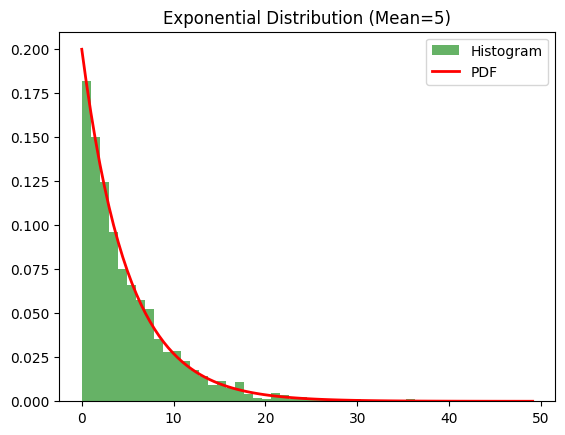

In [8]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Mean is 5, so scale (beta) is 5
samples = np.random.exponential(scale=5, size=2000)

plt.hist(samples, bins=50, density=True, alpha=0.6, color='g', label='Histogram')
x = np.linspace(0, max(samples), 100)
plt.plot(x, stats.expon.pdf(x, scale=5), 'r', lw=2, label='PDF')
plt.legend()
plt.title("Exponential Distribution (Mean=5)")
plt.show()

Explanation: We generate 2,000 samples from an exponential distribution 1 . The histogram shows the frequency of outcomes, while the PDF curve shows the theoretical shape of the distribution 1 .

CLT (Central Limited Theorem)

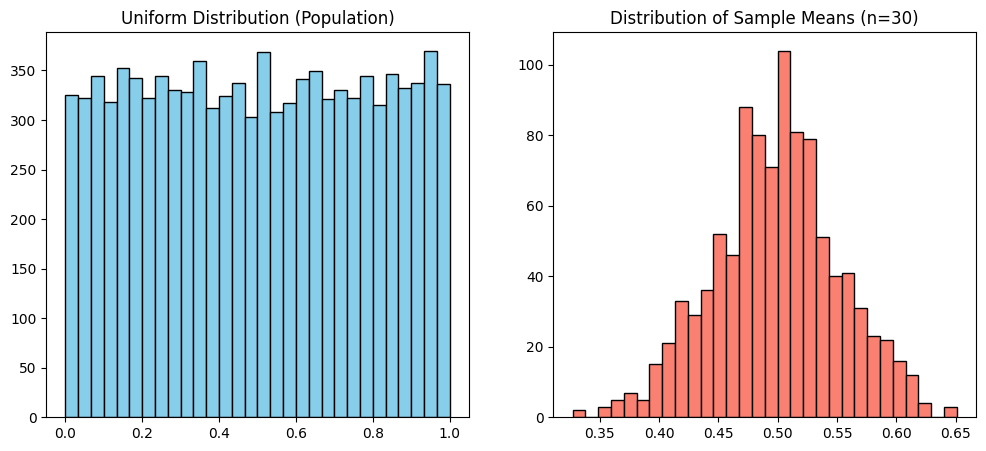

In [9]:
# 6a. 10,000 random numbers from uniform distribution
uniform_data = np.random.uniform(0, 1, 10000)

# 6b. 1000 samples of size n=30
sample_means = [np.mean(np.random.choice(uniform_data, 30)) for _ in range(1000)]

# 6c. Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(uniform_data, bins=30, color='skyblue', edgecolor='black')
ax[0].set_title("Uniform Distribution (Population)")
ax[1].hist(sample_means, bins=30, color='salmon', edgecolor='black')
ax[1].set_title("Distribution of Sample Means (n=30)")
plt.show()

Explanation: Even though the original data is "flat" (uniform), the distribution of the means of small samples from that data forms a bell-shaped "normal" curve. This is the core of the Central Limit Theorem